# **Trabajo final:** EXPLORACIÓN, ENTRENAMIENTO DE MODELOS, CLASIFICACIÓN Y EVALUACIÓN COMPARATIVA ESTADÍSTICA  
Autora: Iraida Abad
## Descripción del dataset  
Dataset elegido: [KU-HAR: Human Activity Recognition Dataset](https://www.kaggle.com/datasets/niloy333/kuhar/data)    

El dataset cuenta con tres archivos principales:
- **Raw_ time_ domian_ data.zip**: Contiene 1945 muestras de datos en dominio temporal en distintos archivos.csv.
- **Trimmed_ interpolated_ raw_ data.zip**: Dataset sin las partes innecesarias. Se han interpolado las muestras para mantener una tasa de muestreo de 100Hz.
- **Time_ domain_ subsamples.zip**: Contiene 20750 submuestras obtenidas de las 1945 muestras originales. Cada submuestra contiene 3 segundos de datos sin solapamiento de cada actividad registrada. 
Este será el archivo que utilizaremos. Los datos se organizan de la siguiente manera:
    - Columnas 1-300, 301-600, 601-900: Ejes X, Y, Z del acelerómetro, cada columna representa una medición puntual separada por 1/100 segundos (10ms) dentro de una ventana de 3s.
    - Columnas 901-1200, 1201-1500, 1501-1800: Ejes X, Y, Z del giroscopio.
    - Columna 1801: Actividad (etiqueta/clase a predecir).
    - Columna 1802: Longitud de cada canal en la submuestra. (No usaremos esta columna).
    - Columna 1803: Número de serie de cada submuestra.


Este dataset recoge información de 18 actividades humanas distintas recogidas de 90 participantes mediante sensores de teléfonos móviles (acelerómetro y giroscopio).  

Estas son las actividades/clases que se recogen:
1. Estar de pie
2. Sentado
3. Hablar estando sentado (haciendo gestos con las manos)
4. Hablar estando de pie (haciendo gestos con las manos)
5. Levantarse y sentarse
6. Tumbarse
7. Levantarse y tumbarse
8. Recoger un objeto del suelo
9. Saltar
10. Hacer flexiones
11. Hacer abdominales
12. Caminar en linea recta
13. Caminar hacia atras en linea recta
14. Caminar en circulos
15. Correr
16. Subir escaleras
17. Bajar escaleras
18. Jugar ping pong  

El objetivo de este dataset es clasificar correctamente las actividades basándonos en las señales recogidas por los sensores.

In [1]:
import pandas as pd
import numpy as np


dataset = pd.read_csv('KU-HAR_time_domain_subsamples_20750x300.csv', header=None)
X = dataset.iloc[:, :1800]  

class_names = [
    "Stand",                    # 0: Estar de pie
    "Sit",                      # 1: Sentado
    "Talk-sit",                 # 2: Hablar sentado (gestos)
    "Talk-stand",               # 3: Hablar de pie (gestos)
    "Stand-sit",                # 4: Levantarse/sentarse
    "Lay",                      # 5: Tumbarse
    "Lay-stand",                # 6: Levantarse/tumbarse
    "Pick",                     # 7: Recoger objeto suelo
    "Jump",                     # 8: Saltar
    "Push-up",                  # 9: Flexiones
    "Sit-up",                   # 10: Abdominales
    "Walk",                     # 11: Caminar recto
    "Walk-backward",            # 12: Caminar atrás
    "Walk-circle",              # 13: Caminar círculos
    "Run",                      # 14: Correr
    "Stair-up",                 # 15: Subir escaleras
    "Stair-down",               # 16: Bajar escaleras
    "Table-tennis"              # 17: Ping pong
]
y = dataset[1800]  # la columna 1800 contiene las etiquetas  
y_labels = pd.Categorical.from_codes(y, class_names)


## Gráficas de visualzación

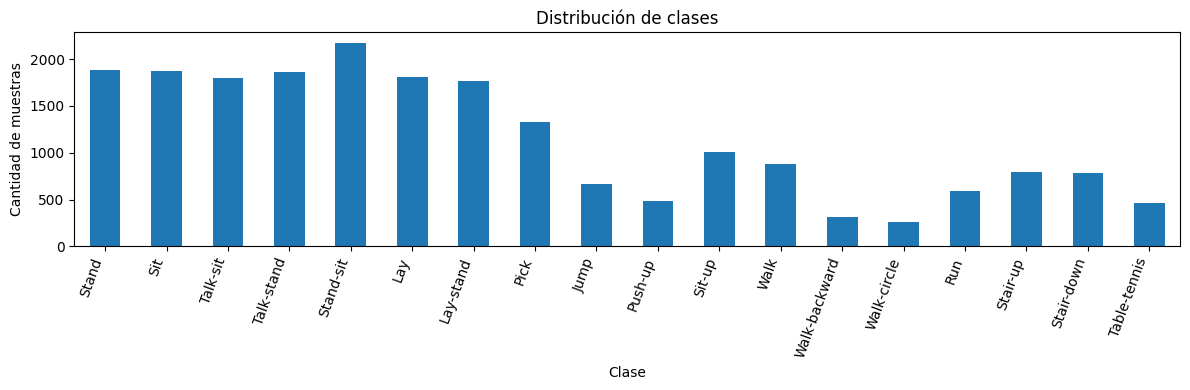

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns



plt.figure(figsize=(12, 4))
y.value_counts().sort_index().plot(kind='bar')
counts = y_labels.value_counts().sort_index()
plt.title('Distribución de clases')
plt.xlabel('Clase'); 
plt.xticks(range(len(counts)), class_names, rotation=70, ha='right')
plt.ylabel('Cantidad de muestras')
plt.tight_layout() 
plt.show()

En este gráfico se puede ver la distribución de las distintas actividades. Podemos observar que hay un desbalance notorio entre las siete primeras clase (con más de 1700 muestras cada una) y las clases restantes (la mayoría con menos de de 1000 muestras).

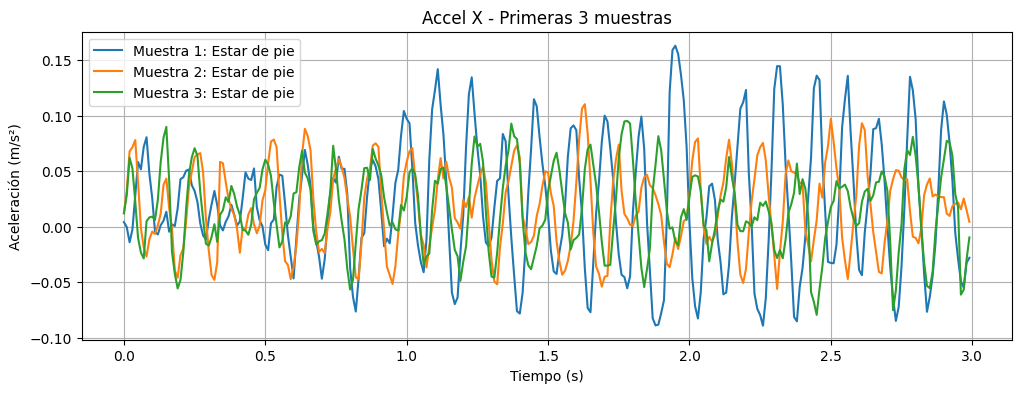

In [3]:
plt.figure(figsize=(12, 4))
time = np.arange(300) / 100  
for i in range(3):
    plt.plot(time, X.iloc[i, :300], label=f'Muestra {i+1}: Estar de pie')
plt.title('Accel X - Primeras 3 muestras')
plt.xlabel('Tiempo (s)'); plt.ylabel('Aceleración (m/s²)')
plt.legend()
plt.grid(True)
plt.show()

En este segundo gráfico podemos observar el comportamiento de las tres primeras muestras (pertencientes a la clase "Estar de pie") en el eje X del acelerómetro. Como podemos ver, las tres señales son parecidas entre ellas, ya que representan la misma acción. 

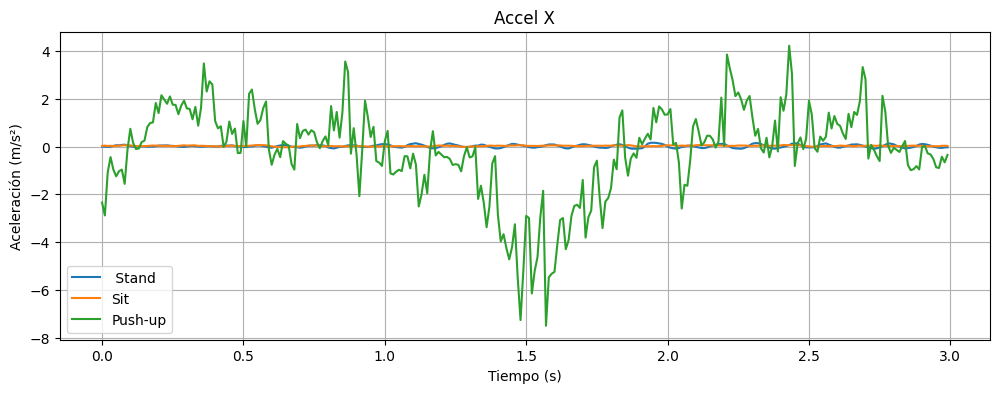

In [4]:
plt.figure(figsize=(12, 4))
time = np.arange(300) / 100  
plt.plot(time, X.iloc[0, :300], label=f' {class_names[int(y.astype(int).iloc[0])]}')
plt.plot(time, X.iloc[2000, :300], label=f'{class_names[int(y.astype(int).iloc[2000])]}')
plt.plot(time, X.iloc[20740, :300], label=f'{class_names[int(y.astype(int).iloc[20740])]}')
plt.title('Accel X')
plt.xlabel('Tiempo (s)'); plt.ylabel('Aceleración (m/s²)')
plt.legend()
plt.grid(True)
plt.show()

En cambio, si comparamos la aceleración en el eje X de tres muestras de señales de distinta clase (Estar de pie, Estar sentado y hacer flexiones), podemos observar una diferencia mayor entre las señales.

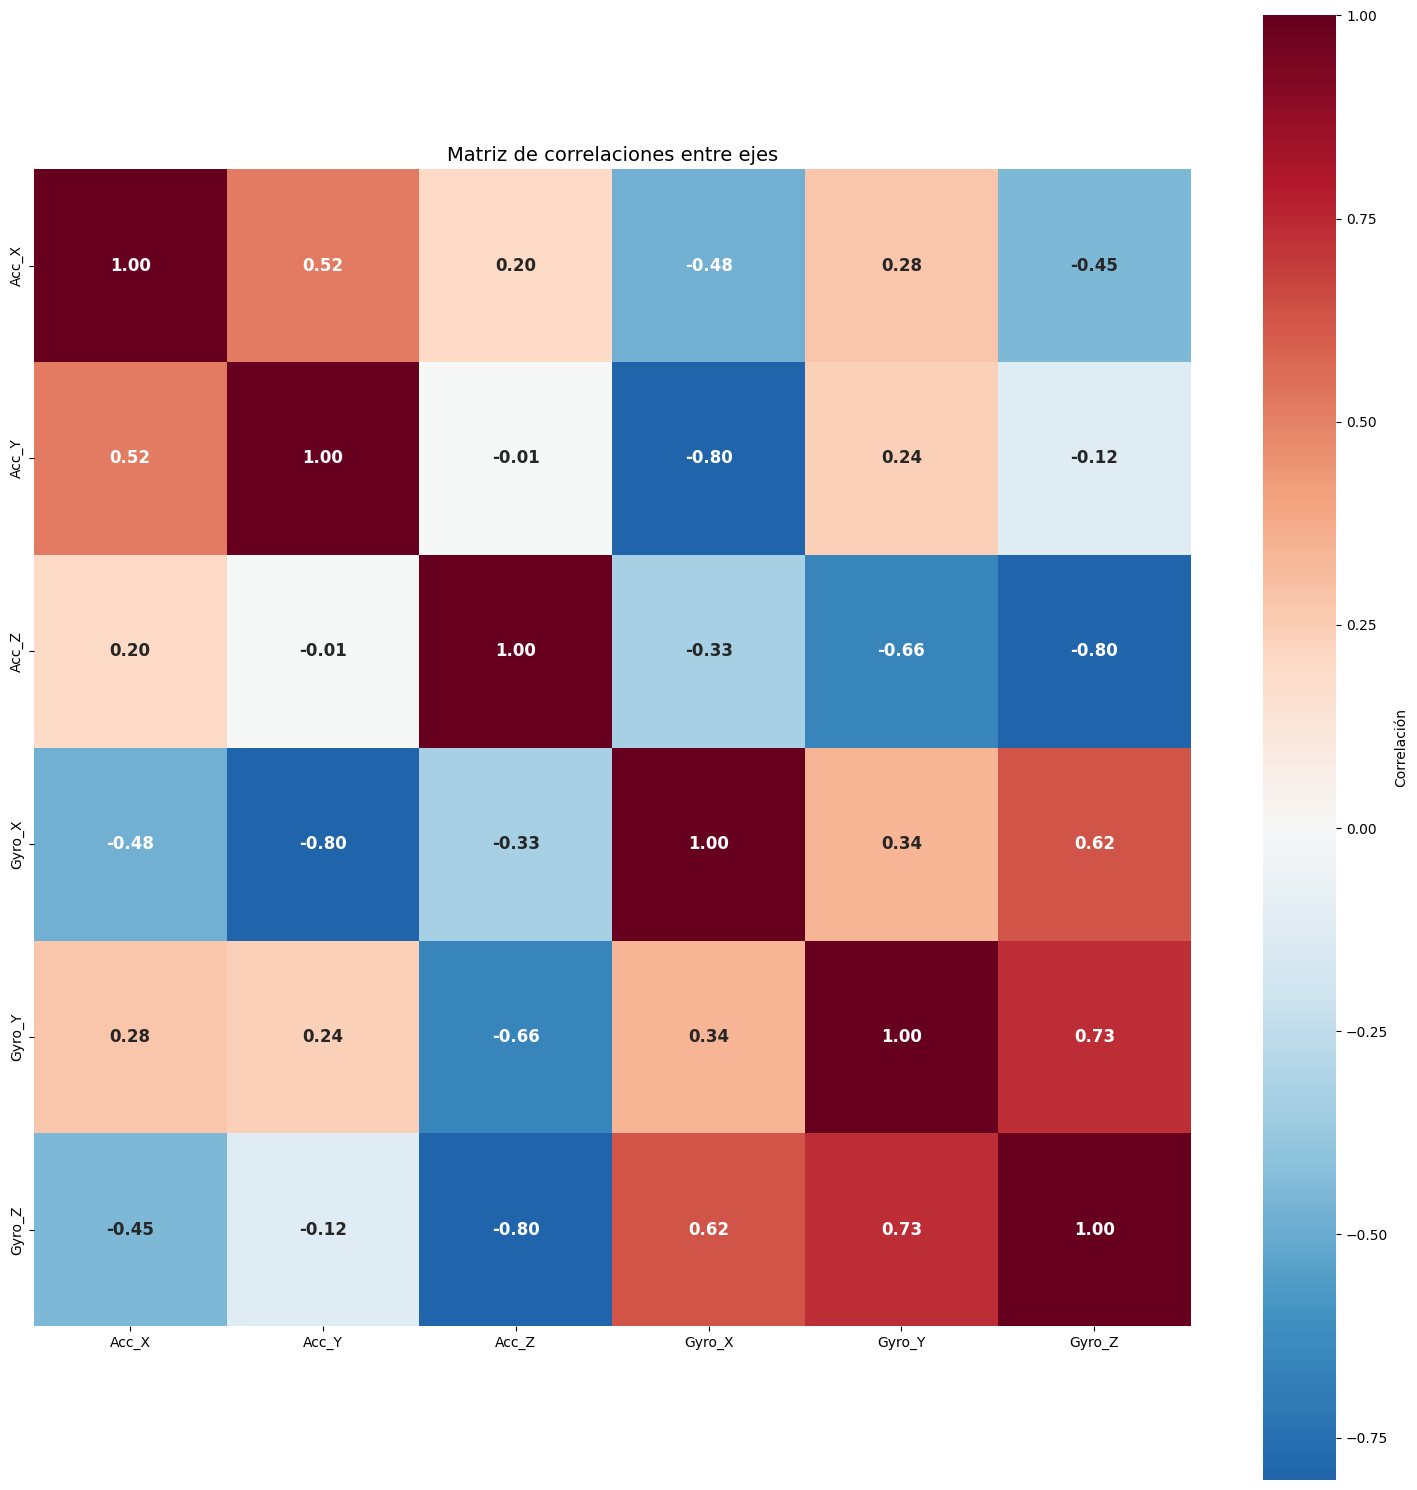

In [67]:
def summarize_axis(start, end):
    return X.iloc[:, start:end].mean(axis=1) #coger todas las filas de las columnas de start a end y hacer la media

ejes = {
    'Acc_X': summarize_axis(0, 300), 
    'Acc_Y': summarize_axis(300, 600),
    'Acc_Z': summarize_axis(600, 900),
    'Gyro_X': summarize_axis(900, 1200),
    'Gyro_Y': summarize_axis(1201, 1500),
    'Gyro_Z': summarize_axis(1501, 1800)
}
df_ejes = pd.DataFrame(ejes)
corr_ejes = df_ejes.corr()

plt.figure(figsize=(15, 15))
sns.heatmap(corr_ejes, 
            annot=True, 
            fmt='.2f', 
            cmap='RdBu_r', center=0, square=True,
            xticklabels=corr_ejes.columns,  
            yticklabels=corr_ejes.columns,  
            annot_kws={'size':12, 'weight':'bold'},
            cbar_kws={'label': 'Correlación'})
plt.title('Matriz de correlaciones entre ejes', fontsize=14)
plt.tight_layout()
plt.show()



Si observamos las correlaciones entre las distintas variables (ejes X, Y y Z del acelerómetro y giroscopio), podemos observar que las variables medidas con la misma herramienta tienen una correlación mayor entre ellas que las que se han medido con herramientas distintas. De hecho, la correlación entre la mayoría de las variables medidas con el giroscopio y las medidas con el acelerómetro es negativa.  
De este gráfico podemos deducir que no hay redundancia entre las variables predictoras.  
## Detección de outliers  
Antes de realizar la detección de outliers, vamos a hacer un análisis de componentes principales (PCA) para reducir la dimensionalidad de los datos y poder visualizarlos en 3D.    

Para ello, primero vamos a conseguir la media y la desviación estándar de los 3 segundos de cada variable (es decir, la media y la desviación estándar de las columnas 1-300 para la aceleración en X, la media y la desviación de las columnas 301-600 para la aceleración en Y, etc). De este modo, reducimos las 1800 variables originales a 6 variables (media y desviación estándar de cada una de las 6 señales del acelerómetro y giroscopio).

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import plotly.express as px  


def stats_axis(data, start, end, name):
    block = data.iloc[:, start:end]
    means = block.mean(axis=1).rename(f'{name}_mean')
    stds = block.std(axis=1).rename(f'{name}_std')
    return pd.concat([means, stds], axis=1)


stats_list = [
    stats_axis(X, 0, 300, 'AccX'),
    stats_axis(X, 300, 600, 'AccY'),
    stats_axis(X, 600, 900, 'AccZ'),
    stats_axis(X, 900, 1200, 'GyroX'),
    stats_axis(X, 1200, 1500, 'GyroY'),
    stats_axis(X, 1500, 1800, 'GyroZ')
]

stats = pd.concat(stats_list, axis=1)  

scaler = StandardScaler()
stats_scaled = scaler.fit_transform(stats) 

Primero, vamos a hacer un PCA sin delimitar el número de componentes para observar la varianza explicada por cada componente principal.

In [7]:
pca = PCA()
pca.fit(stats_scaled)
n_comp = 12 

summary_pca = pd.DataFrame({
    'Standard deviation': np.sqrt(pca.explained_variance_),
    'Proportion of Variance': pca.explained_variance_ratio_,
    'Cumulative Proportion': np.cumsum(pca.explained_variance_ratio_)
}, index=[f'PC{i+1}' for i in range(n_comp)])

print("=== SUMMARY PCA ===")
print(summary_pca.round(4))

=== SUMMARY PCA ===
      Standard deviation  Proportion of Variance  Cumulative Proportion
PC1               2.3708                  0.4684                 0.4684
PC2               1.7765                  0.2630                 0.7314
PC3               1.2540                  0.1310                 0.8624
PC4               0.7863                  0.0515                 0.9139
PC5               0.6176                  0.0318                 0.9457
PC6               0.5788                  0.0279                 0.9736
PC7               0.4293                  0.0154                 0.9890
PC8               0.3414                  0.0097                 0.9987
PC9               0.1229                  0.0013                 0.9999
PC10              0.0224                  0.0000                 1.0000
PC11              0.0101                  0.0000                 1.0000
PC12              0.0054                  0.0000                 1.0000


Como se puede observar en la tabla, las cuatro primeras componentes principales explican el 91.39% de la varianza total de los datos, y las tres primeras el 86.24%. Por lo tanto, si visualizamos los datos en 3D, no perderemos demasiada información.

C:\Users\iraid\AppData\Local\Temp\ipykernel_20984\1434914364.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


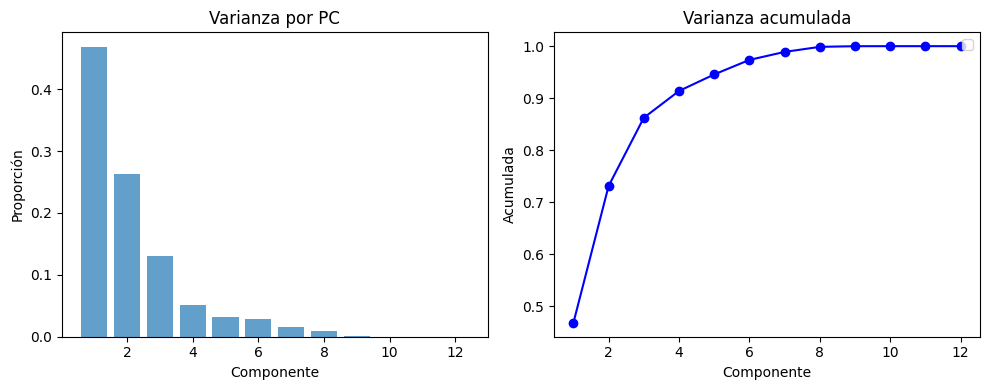

In [8]:
plt.figure(figsize=(10, 4))
plt.subplot(1,2,1)
plt.bar(range(1, n_comp+1), pca.explained_variance_ratio_, alpha=0.7)
plt.title('Varianza por PC'); plt.xlabel('Componente'); plt.ylabel('Proporción')

plt.subplot(1,2,2)
plt.plot(range(1, n_comp+1), np.cumsum(pca.explained_variance_ratio_), 'bo-')
plt.title('Varianza acumulada'); plt.xlabel('Componente'); plt.ylabel('Acumulada')
plt.legend()
plt.tight_layout()
plt.show()

En estos dos gráficos podemos confirmar que las tres primeras componentes principales explican la mayoría de la varianza de los datos.

In [9]:
X_pca_all = pca.transform(stats_scaled)      
X_pca_3 = X_pca_all[:, :3]                   # PC1, PC2, PC3


df_pca3 = pd.DataFrame(X_pca_3, columns=['PC1','PC2','PC3'])
df_pca3['clase'] = y_labels[:len(df_pca3)]

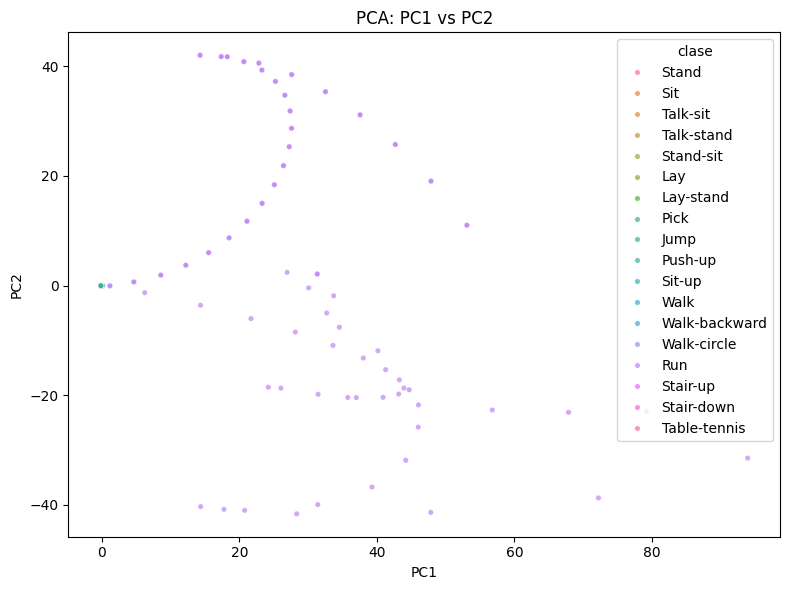

In [10]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df_pca3, x='PC1', y='PC2', hue='clase', s=15, alpha=0.7)
plt.title('PCA: PC1 vs PC2')
plt.tight_layout()
plt.show()

En esta primera vista podemos ver que las muestras pertenecientes a la clase 'run' son las que más se esparcen por el espacio, haciendo que la escala de los ejes sea mayor y dificultando la visualización de las demás clases.  
Para solucionarlo, en la siguiente gráfica he eliminado las muestras de la clase 'run' para observar mejor las demás clases.

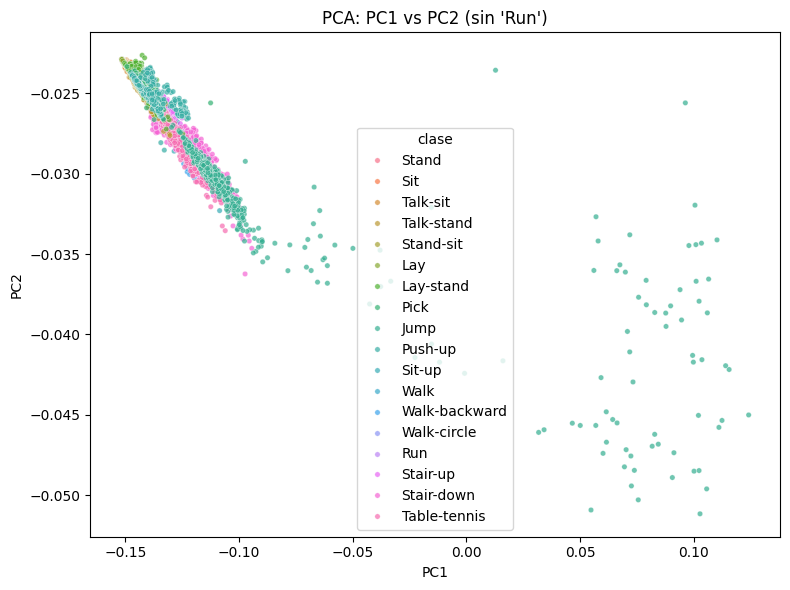

In [11]:
df_no_run = df_pca3[(df_pca3['clase'] != 'Run')]  

plt.figure(figsize=(8,6))
sns.scatterplot(data=df_no_run, x='PC1', y='PC2', hue='clase', s=15, alpha=0.7)
plt.title("PCA: PC1 vs PC2 (sin 'Run')")
plt.tight_layout()
plt.show()


Eliminando las muestras de la clase run, podemos observar que el resto de clases se agrupan en la misma zona, a excepción de la clase 'jump', que se separa un poco más del resto.

In [12]:
fig = px.scatter_3d(df_pca3,
                    x='PC1', y='PC2', z='PC3', color='clase',
                    title=f'PCA (varianza: 86.24%)')

fig.update_traces(marker=dict(
    size=4,        # Tamaño fijo (pixeles)
    sizemode='diameter',  # 'diameter' o 'area'
    sizeref=1      # Escala (1=normal)
))

fig.show()

Al igual que con la gráfica en 2D, las muestras de la clase run se dispersan más que las demás por el espacio, dificultando la visualización de las otras clases.  
Para poder visualizar las demás clases, es necesario ocultar la clase 'run', clicando en la leyenda.  

Si oculamos las clases 'run' y 'jump', podemos observar que las muestras de las demás clases se agrupan entre ellas y que las clases tienden a agruparse por la misma zona, pudiendo complicar la distinción clara entre los distintos clusters.

  
  ---
     

Vamos a realizar la detección de outliers utilizando el método de Isolation Forest.

In [3]:
import warnings
warnings.filterwarnings("ignore", message=".*Returning the number of logical cores instead.*")
from sklearn.ensemble import IsolationForest

La contaminación representa la proporción estimada de outliers en el dataset. La estableceremos al 5%, ya que no esperamos demasiados outliers en los datos.

In [14]:
contamination = 0.05

In [15]:
iso = IsolationForest(contamination=contamination, random_state=42)  
outliers_iso = iso.fit_predict(stats_scaled)  # -1=outlier, 1=normal
df_outliers = df_pca3.copy()
df_outliers['outlier_iso'] = outliers_iso
print("Outliers globales:", (outliers_iso == -1).sum())

Outliers globales: 1038


Text(0.5, 1.0, 'Detección de outliers globales')

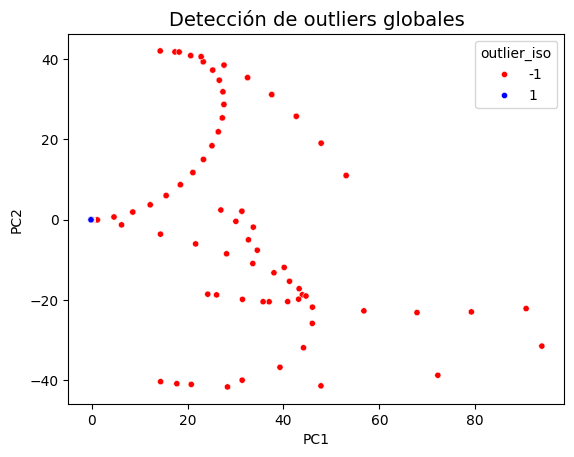

In [16]:
sns.scatterplot(data=df_outliers, x='PC1', y='PC2', 
                hue='outlier_iso', palette={1:'blue', -1:'red'}, s=20)
plt.title("Detección de outliers globales", fontsize=14)

Como era de esperar, Isolation Forest ha detectado la clase 'run' como outliers, aunque no lo sean, ya que sus valores alejados son por la naturaleza de la actividad. 
Para evitar este problema, vamos a realizar la detección de outliers por cada clase.

Outliers clase 'Stand': 95/1886
Outliers clase 'Sit': 94/1874
Outliers clase 'Talk-sit': 90/1797
Outliers clase 'Talk-stand': 94/1866
Outliers clase 'Stand-sit': 109/2178
Outliers clase 'Lay': 91/1813
Outliers clase 'Lay-stand': 89/1762
Outliers clase 'Pick': 67/1333
Outliers clase 'Jump': 34/666
Outliers clase 'Push-up': 24/480
Outliers clase 'Sit-up': 51/1005
Outliers clase 'Walk': 45/882
Outliers clase 'Walk-backward': 16/317
Outliers clase 'Walk-circle': 13/259
Outliers clase 'Run': 30/595
Outliers clase 'Stair-up': 40/798
Outliers clase 'Stair-down': 39/781
Outliers clase 'Table-tennis': 23/458


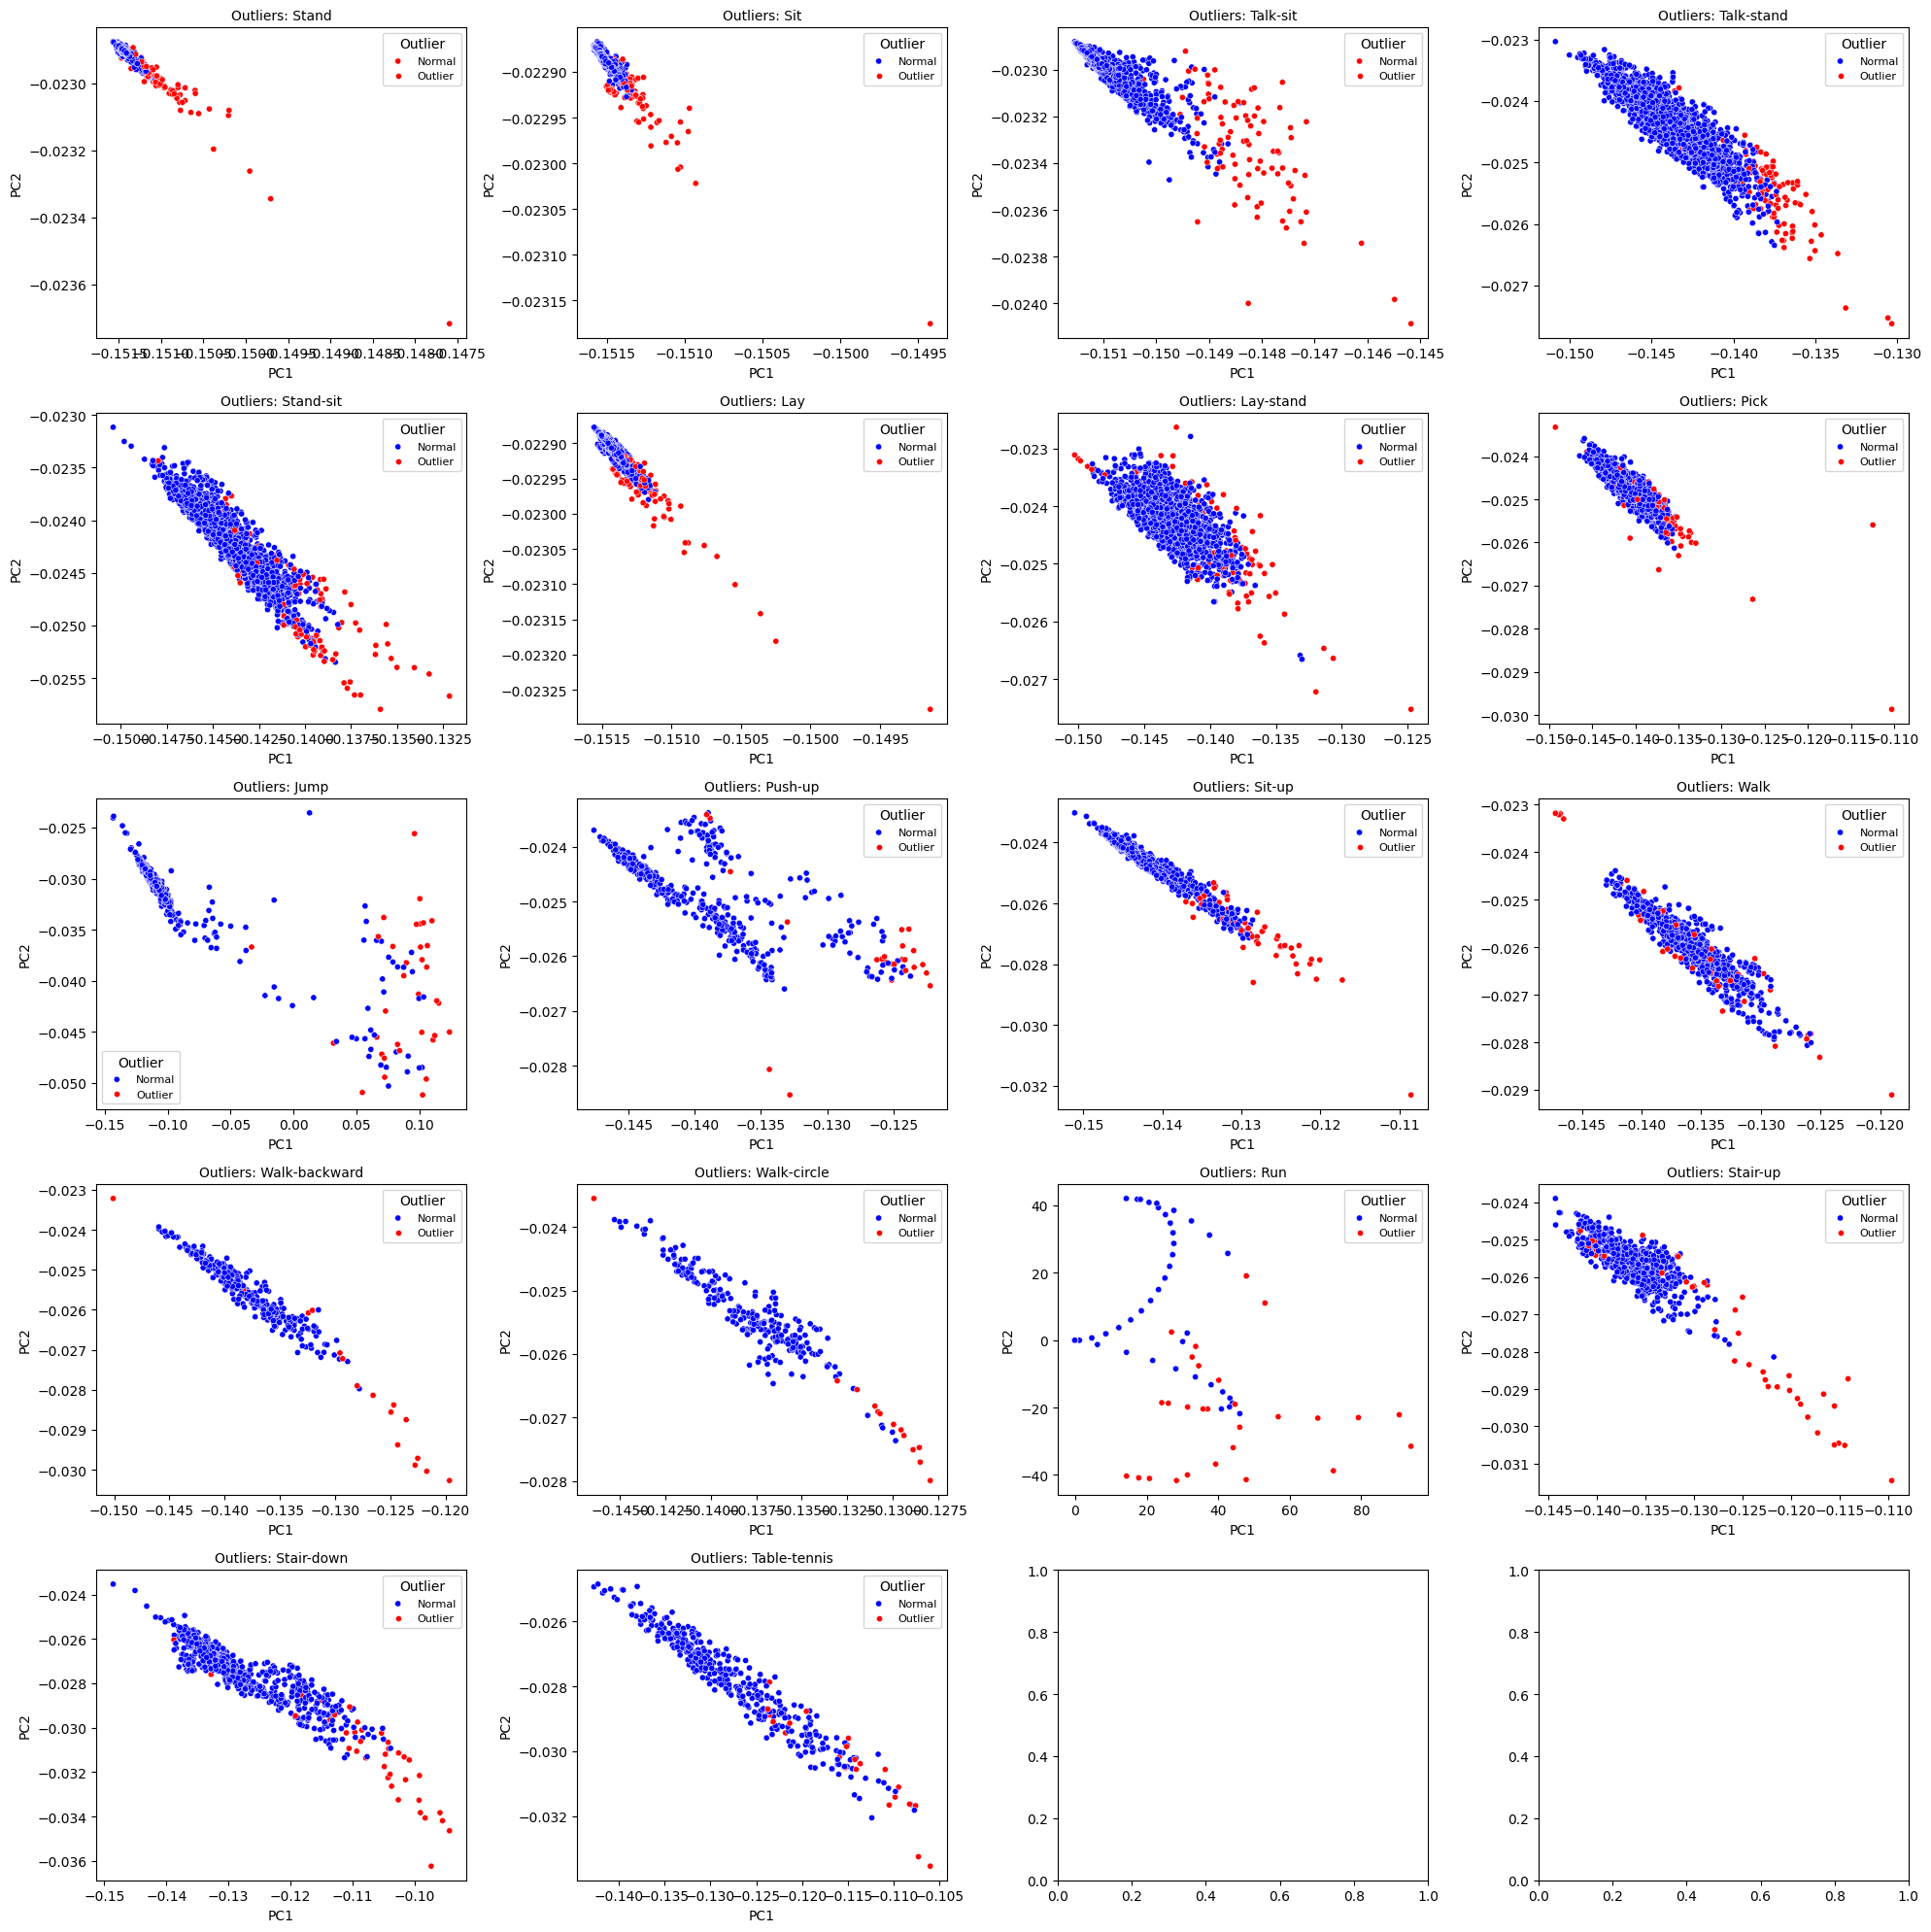

In [17]:
clases_a_analizar = [
    "Stand", "Sit", "Talk-sit", "Talk-stand", "Stand-sit", "Lay", "Lay-stand",
    "Pick", "Jump", "Push-up", "Sit-up", "Walk", "Walk-backward",
    "Walk-circle", "Run", "Stair-up", "Stair-down", "Table-tennis"
]

outliers_por_clase = {}

for clase in clases_a_analizar:
    # Filtrar datos de la clase
    X_clase = stats_scaled[df_pca3['clase'] == clase]
    df_clase = df_pca3[df_pca3['clase'] == clase]
    
    # Aplicar Isolation Forest
    outliers_clase = iso.fit_predict(X_clase)
    
    # Guardar resultados
    df_outliers_clase = df_clase.copy()
    df_outliers_clase['outlier_iso'] = outliers_clase
    outliers_por_clase[clase] = df_outliers_clase
    
    # Imprimir cantidad de outliers
    n_outliers = (outliers_clase == -1).sum()
    print(f"Outliers clase '{clase}': {n_outliers}/{len(X_clase)}")

# Visualizar 
fig, axes = plt.subplots(5, 4, figsize=(20, 20))
axes = axes.flatten()

for idx, clase in enumerate(clases_a_analizar):
    df_plot = outliers_por_clase[clase]
    sns.scatterplot(data=df_plot, x='PC1', y='PC2', 
                    hue='outlier_iso', palette={1:'blue', -1:'red'}, 
                    s=20, ax=axes[idx])
    axes[idx].set_title(f"Outliers: {clase}", fontsize=10)
    axes[idx].legend(title='Outlier', labels=['Normal', 'Outlier'], fontsize=8)

plt.tight_layout()
plt.show()

Ahora que hemos realizado la detección por clase, podemos observar mucho mejor los outliers reales.  
Teniendo en cuenta la naturaleza de cada actividad y que los datos representan mediciones reales, no vamos a eliminar los outliers, ya que estos representan una variabilidad real, no errores de medición.  
Eliminar estos outliers pordría empobrecer el modelo y su capacidad de generalización.    

## Clasificación supervisada  

Para el entrenamiento de los modelos de clasificación supervisada se utilizará el conjunto de datos formado por las medias y las desviaciones estándar de las señales registradas durante 3 segundos para cada eje del acelerómetro y giroscopio. Esta representación reduce significativamente la dimensionalidad del problema, mejora la interpretabilidad de las variables y disminuye el coste computacional.

Separaremis el dataset en conjuntos de entrenamiento y prueba. El 80% de los datos se utilizarán para entrenar el modelo y el 20% restante para evaluarlo.

In [4]:
from sklearn.metrics import accuracy_score  
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder


X_stats = stats.copy()

X_train, X_test, y_train, y_test = train_test_split(
    X_stats, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

X_train = X_train_scaled
X_test = X_test_scaled


Para la clasificación supervisada utilizaremos un modelo lineal de regresión logística como baseline, un modelo basado en árboles como  el Random Forest y XGBoost.  

*(Probaremos la eficiencia de los modelos con el dataset sin modificar para decidir si aplicar algún metodo de resampling, ya que los modelos incluyen la opción de ajustar los pesos de las clases desbalanceadas)*  

Para comparar los modelos utilizaremos el F1 score, ya que es una métrica adecuada para datasets desbalanceados, aunque también calcularemos la media.

### Modelo lienal
Para el modelo lineal de regresión logística utilizaremos el paquete de `LogisticRegression` de `sklearn`.  
Estos son los parámetros que se utilizarán:
- **L1_ratio (penalty):** Tipo de regularización. Utilizaremos 'L2' ya que es más estable.
- **C:** Fuerza de regularización. Para que el modelo no se sobreajuste utilizaremos el valor por defecto 1.0.
- **solver:** Algoritmo de optimización. Utilizaremos 'lbfgs', que es el que aparece por defecto y es util para problemas multiclase con penalización L2.
- **max_iter:** Número máximo de iteraciones para el algoritmo de optimización. Para intentar asegurar la convergencia del modelo, probaremos los valores 500 y 1000.
- **class_weight:** Peso que se le asocia a las clases. Utilizaremos 'balanced' para ajustar los pesos inversamente proporcionales a las frecuencias de las clases, ya que el dataset está desbalanceado.  

**ATENCIÓN: LA SIGUIENTE CELDA PUEDE TARDAR HASTA 27 MINUTOS EN EJECUTARSE**

In [9]:
from sklearn.metrics import classification_report

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

log_reg = LogisticRegression(penalty = 'l2', 
                             C=1.0, 
                             solver='lbfgs', 
                             class_weight='balanced',
                             random_state=42)



param_log = {
    'max_iter': [500, 1000]
}


grid_log = GridSearchCV(
    log_reg,
    param_log,
    scoring='f1_macro',  
    cv=5,
    n_jobs=-1
)

grid_log.fit(X_train, y_train)

best_log = grid_log.best_estimator_
print("Best params:", grid_log.best_params_)

Best params: {'max_iter': 1000}


C:\Users\iraid\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning:

lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression



In [6]:
import joblib

In [40]:
joblib.dump(best_log, 'mejor_logreg.joblib')

['mejor_logreg.joblib']

In [ ]:
best_log = joblib.load('mejor_logreg.joblib')
best_log.fit(X_train, y_train)

In [ ]:
y_pred_log = best_log.predict(X_test)
print("Logistic Regression Report:", classification_report(y_test, y_pred_log))

Logistic Regression Report:               precision    recall  f1-score   support

           0       0.00      0.00      0.00       377
           1       0.15      1.00      0.27       375
           2       0.00      0.00      0.00       359
           3       0.50      0.33      0.40       373
           4       1.00      0.01      0.01       436
           5       0.00      0.00      0.00       363
           6       0.85      0.15      0.26       352
           7       0.00      0.00      0.00       267
           8       0.45      0.99      0.62       133
           9       0.60      0.09      0.16        96
          10       0.31      0.68      0.43       201
          11       0.59      0.17      0.26       176
          12       0.16      0.05      0.07        63
          13       0.34      0.21      0.26        52
          14       1.00      0.36      0.53       119
          15       0.71      0.03      0.06       160
          16       0.36      0.40      0.38       156

C:\Users\iraid\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\iraid\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\iraid\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_clas

### Random Forest
Para el modelo de Random Forest utilizaremos el paquete de `RandomForestClassifier` de `sklearn`.
Parámetros a utilizar:
- **n_estimators:** Número de árboles en el bosque. Utilizaremos 300 y 500árboles para un buen equilibrio entre rendimiento y estabilidad.
- **max_depth:** Profundidad máxima de cada árbol. Para evitar el sobreajuste, limitaremos la profundidad a 7 y 10 niveles, ya que árboles más profundos pueden aprender patrones demasiado específicos.
- **min_samples_leaf:** Número mínimo de muestras en una hoja. Estableceremos el valor en 2 y 5 para suavizar el ruido.
- **class_weight:** Peso que se le asocia a las clases. Utilizaremos 'balanced' para ajustar los pesos inversamente proporcionales a las frecuencias de las clases.


**ATENCIÓN: LA SIGUIENTE CELDA PUEDE TARDAR HASTA 25 MINUTOS EN EJECUTARSE**

In [39]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators': [300, 500],
    'max_depth': [7, 10],
    'min_samples_leaf': [2, 5]
}

rf = RandomForestClassifier(
    class_weight='balanced',
    random_state=42
)

grid_rf = GridSearchCV(
    rf,
    param_grid,
    scoring='f1_macro',  
    cv=5,
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_
print("Best params:", grid_rf.best_params_)

Best params: {'max_depth': 10, 'min_samples_leaf': 5, 'n_estimators': 500}


Sabiendo cual es el mejor modelo de Random Forest, procedemos a evaluarlo en el conjunto de test. Una vez conocidos los hiperparámetros óptimos, entrenar el modelo apenas tarda un segundo.

In [43]:
joblib.dump(best_rf, 'mejor_rf.joblib')

['mejor_rf.joblib']

In [ ]:
best_rf = joblib.load('mejor_rf.joblib')
best_rf.fit(X_train, y_train)

In [ ]:
y_pred_rf = best_rf.predict(X_test)
print("Random Forest Report:", classification_report(y_test, y_pred_rf))

Random Forest Report:               precision    recall  f1-score   support

           0       0.87      0.87      0.87       377
           1       0.93      0.91      0.92       375
           2       0.90      0.95      0.92       359
           3       0.96      0.92      0.94       373
           4       0.93      0.95      0.94       436
           5       0.93      0.91      0.92       363
           6       0.96      0.92      0.94       352
           7       0.85      0.90      0.88       267
           8       0.99      0.92      0.95       133
           9       0.97      0.91      0.94        96
          10       0.88      0.81      0.84       201
          11       0.71      0.76      0.73       176
          12       0.49      0.62      0.55        63
          13       0.68      0.83      0.75        52
          14       0.90      0.96      0.93       119
          15       0.87      0.91      0.89       160
          16       0.90      0.79      0.84       156
     

### XGBoost  
Para el modelo de XGBoost utilizaremos el paquete `xgboost`.  

Dado el elevado conste computacional de XGBoost, se ha limitado el proceso de optimización a los hiperparámetros más influyentes:   

- **n_estimators:** Número de árboles en el modelo. Utilizaremos 150 y 300.
- **max_depth:** Profundidad máxima de cada árbol. Al igual que en Random Forest, limitaremos la profundidad a 3 y 5.
- **learning_rate:** Tasa de aprendizaje. Probaremos con el valor 0.1.

**ATENCIÓN: EL SIGUIENTE BLOQUE DE CÓDIGO HA TARDADO HASTA 111 MINUTOS EN EJECUTARSE COMPLETAMENTE.**  

In [ ]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV



xgb_clf = xgb.XGBClassifier(
    objective='multi:softprob',      
    num_class=len(np.unique(y_train)),                   
    eval_metric='mlogloss',         
    random_state=42)

params_xgb = {
    'n_estimators': [150, 300],
    'max_depth': [3, 5],
    'learning_rate': [0.1]
}


grid_xgb = GridSearchCV(
    estimator=xgb_clf,
    param_grid=params_xgb,
    scoring='f1_macro',     
    cv=3,
    n_jobs=1,
    verbose=1
)

grid_xgb.fit(X_train, y_train)

best_xgb = grid_xgb.best_estimator_

print("Best params:", grid_xgb.best_params_)

Fitting 3 folds for each of 4 candidates, totalling 12 fits
Best params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 300}


In [ ]:
joblib.dump(best_xgb, 'mejor_xgboost.joblib')

['mejor_xgboost.joblib']

In [16]:
best_xgb = joblib.load('mejor_xgboost.joblib')
best_xgb.fit(X_train, y_train)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


Evaluamos el mejor modelo de XGBoost en el conjunto de test:

In [17]:
y_pred_xgb = best_xgb.predict(X_test)

print("XGBoost Report:", classification_report(y_test, y_pred_xgb))

XGBoost Report:               precision    recall  f1-score   support

           0       0.96      0.92      0.94       377
           1       0.95      0.95      0.95       375
           2       0.93      0.99      0.96       359
           3       0.97      0.97      0.97       373
           4       0.97      0.96      0.96       436
           5       0.96      0.95      0.96       363
           6       0.98      0.96      0.97       352
           7       0.91      0.96      0.93       267
           8       1.00      0.95      0.98       133
           9       0.95      0.96      0.95        96
          10       0.91      0.87      0.89       201
          11       0.83      0.88      0.86       176
          12       0.64      0.59      0.61        63
          13       0.92      0.87      0.89        52
          14       0.92      0.99      0.96       119
          15       0.92      0.94      0.93       160
          16       0.97      0.92      0.94       156
          1

### Comparación de modelos  
|Modelo          | Accuracy | F1-score (macro) | F1-score (weighted) | 
|----------------|:--------:|:----------------:|:-------------------:|
| Regresión logística |  25%   |     0.23     |    0.18      |              
| Random Forest |  89%    |    0.87 |   0.90           |                    
| XGBoost             |   94%   |  0.92           |        0.94   |  


Como era de esperar, el modelo de regresión logística es el que peores resultados ha obtenido, ya que, como hemos podido observar en la representación del PCA, este dataset es muy complicado de separar linealmente al estar todas las clases agrupadas en una misma zona.  

El modelo random forest ha conseguido resultado aceptables, alcanzando valores de F1-score de 0.87 en el macro y 0.90 en el ponderado. Sin embargo, el rendimiento varía considerablemente entre las clases, con valores de precisión que oscilan entre el 49% y el 99%, y valores de recall entre 62% y 95%. Esto indica que, aunque el modelo es capaz de capturar relaciones no lineales, presenta dificultades para etiquetar correctamente algunas actividades, especialmente aquellas con patrones más complejos o similares entre sí.

Como era previsible, XGBoost es el modelo que mejor ha actuado, ya que este modelo permite corregir los errores cometidos por árboles anteriores. Con una accuracy del 94% y un F1-score similar, mejorando en un 6% el modelo anterior.  
Al alcancar un accuracy del 94% y que ambos resultados de F1-score son mayores a 0.90, se puede concluir que el modelo gestiona adecuadamente el desbalanceo entre clases, sin necesidad de aplicar técnicas adicionales de resampling.

## Interpretable machine learning  

Para examinar la interpretabilidad del dataset calcularemos los siguientes métodos:  
- SHAP: valora cuanto influye cada variable en la predicción eliminandola y volviendo a calcular la clase.
- Permutation Feature Importance: "rompe" la relación entre las variables predictoras y la clase para determinar la importancia de cada variable a la hora de la predicción.
- Feature Effects: varía el valor de la variable predictora para ver cual es el cambio en la predicción.    

Para las predicciones utilizaremos el modelo XGBoost, ya que ha sido el que mejores resultados ha dado.

### SHAP

In [ ]:
pip install shap

Defaulting to user installation because normal site-packages is not writeable
  Using cached numpy-2.3.5-cp312-cp312-win_amd64.whl.metadata (60 kB)
Using cached numpy-2.3.5-cp312-cp312-win_amd64.whl (12.8 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
Note: you may need to restart the kernel to use updated packages.


  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
alibi 0.9.6 requires numpy<2.0.0,>=1.16.2, but you have numpy 2.3.5 which is incompatible.
gpy 1.13.2 requires numpy<2.0.0,>=1.7, but you have numpy 2.3.5 which is incompatible.
gpy 1.13.2 requires scipy<=1.12.0,>=1.3.0, but you have scipy 1.16.3 which is incompatible.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 2.3.5 which is incompatible.
thinc 8.2.5 requires numpy<2.0.0,>=1.19.0; python_version >= "3.9", but you have numpy 2.3.5 which is incompatible.

[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: C:\Users\iraid\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [18]:
import shap
explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer(X_train)

Para poder visualizar el beeswarm plot y calcular el valor global de cada variable, es necesario calcular la media del valor absoluto de los valores SHAP de cada varaible a lo largo de todas las muestras.

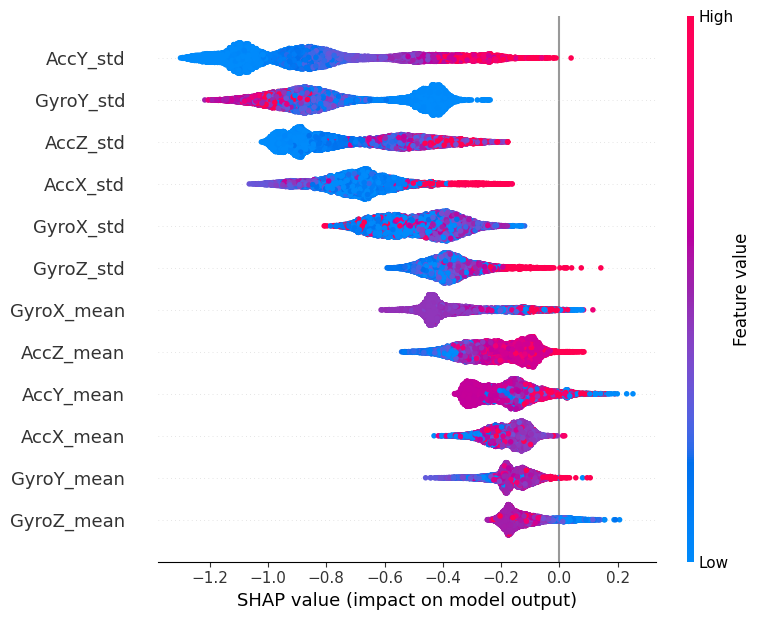

In [ ]:
shap_mean = np.mean(shap_values.values, axis=2)

shap_exp_mean = shap.Explanation(
    values=shap_mean,
    base_values=np.mean(shap_values.base_values, axis=1),
    data=X_train.values,
    feature_names=X_train.columns
)

shap.summary_plot(shap_exp_mean, X_train)

Tal y como podemos observar en el gráfico, la variable más relevante a la hora de predecir la clase es la desviación estándar del eje Y del acelerómetro (la primera variable en la columna). Podemos ver que la mayoría de las muestras tienen un valor negativo entre -1.2 y -0.8 aunque los valores mayores son los que más valor aportan (los pintados de rosa).  
La segunda variable más relevante es la desviación estándar del eje Y del giroscopio. En este caso, los valores más relevantes son los más negativos aunque sean la minoría.  

A medida que vamos observando las demás variables, vemos que tienen valores más cercanos a 0, por lo que influyen menos en la predicción.

### Permutation Feature Importance

In [20]:
feature_names = ['AccX_mean','AccX_std','AccY_mean','AccY_std',
                 'AccZ_mean','AccZ_std','GyroX_mean','GyroX_std',
                 'GyroY_mean','GyroY_std','GyroZ_mean','GyroZ_std']

In [21]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(best_xgb, X_test, y_test, n_repeats=10)

for i in perm.importances_mean.argsort()[::-1]:
    if perm.importances_mean[i] - 2 * perm.importances_std[i] > 0:
        print(f"{feature_names[i]:<8}"
              f"{perm.importances_mean[i]:.3f}"
              f" +/- {perm.importances_std[i]:.3f}")

GyroY_std0.196 +/- 0.004
GyroX_std0.176 +/- 0.002
AccZ_std0.170 +/- 0.004
AccY_std0.157 +/- 0.004
AccX_std0.147 +/- 0.003
GyroZ_std0.119 +/- 0.003
AccZ_mean0.083 +/- 0.002
AccX_mean0.052 +/- 0.002
GyroX_mean0.048 +/- 0.003
GyroY_mean0.017 +/- 0.002
AccY_mean0.015 +/- 0.001
GyroZ_mean0.004 +/- 0.001


Al igual que SHAP, la desviación estándar del eje Y del giroscopio es una de las variables más importantes al realizar las predicciones.

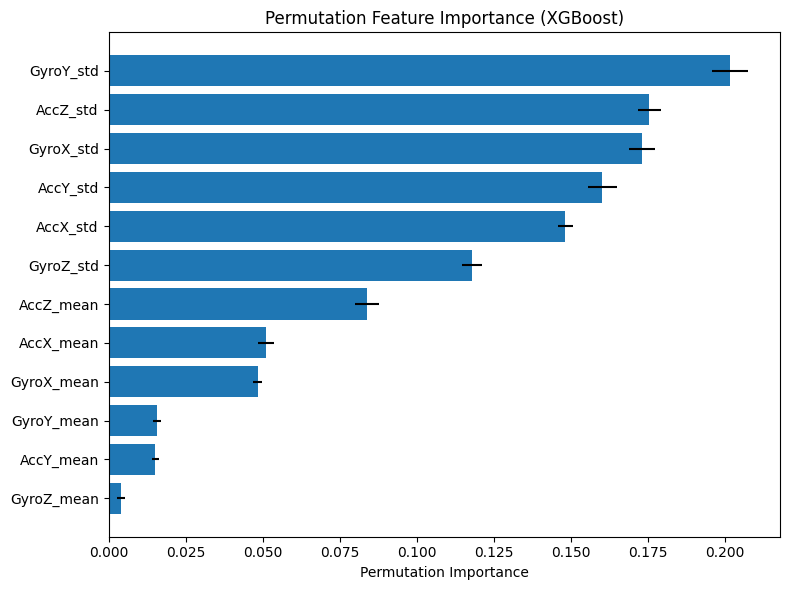

In [35]:
import matplotlib.pyplot as plt
sorted_idx = perm.importances_mean.argsort()

plt.figure(figsize=(8,6))
plt.barh(range(len(feature_names)), perm.importances_mean[sorted_idx],
         xerr=perm.importances_std[sorted_idx], align='center')
plt.yticks(range(len(feature_names)), np.array(feature_names)[sorted_idx])
plt.xlabel("Permutation Importance")
plt.title("Permutation Feature Importance (XGBoost)")
plt.tight_layout()
plt.show()


En el gráfico se puede ver de forma más clara que variables tienen más importancia de cada variable.  
La barra azul representa la importancia mientras que la linea negra representa la desviación estándar.  

### Feature effects 


In [13]:
pip install alibi

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: C:\Users\iraid\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [ ]:
from alibi.explainers import ALE

ale = ALE(best_xgb.predict, feature_names=feature_names)

ale_exp = ale.explain(X_test.values) 

array([[<Axes: xlabel='AccX_mean', ylabel='ALE'>,
        <Axes: xlabel='AccX_std', ylabel='ALE'>,
        <Axes: xlabel='AccY_mean', ylabel='ALE'>],
       [<Axes: xlabel='AccY_std', ylabel='ALE'>,
        <Axes: xlabel='AccZ_mean', ylabel='ALE'>,
        <Axes: xlabel='AccZ_std', ylabel='ALE'>],
       [<Axes: xlabel='GyroX_mean', ylabel='ALE'>,
        <Axes: xlabel='GyroX_std', ylabel='ALE'>,
        <Axes: xlabel='GyroY_mean', ylabel='ALE'>],
       [<Axes: xlabel='GyroY_std', ylabel='ALE'>,
        <Axes: xlabel='GyroZ_mean', ylabel='ALE'>,
        <Axes: xlabel='GyroZ_std', ylabel='ALE'>]], dtype=object)

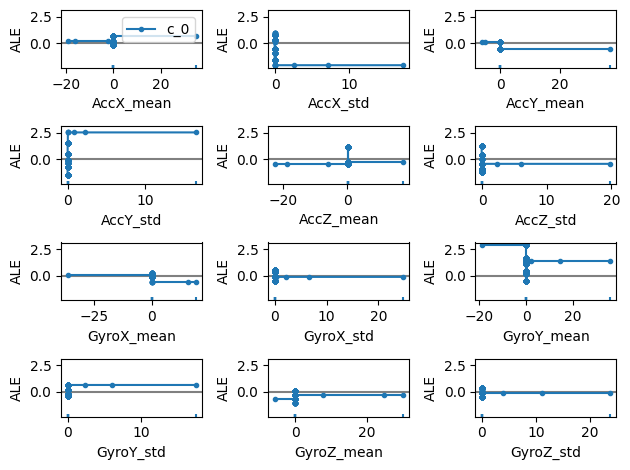

In [ ]:
from alibi.explainers import plot_ale

plot_ale(ale_exp)

En este gráfico podemos observar la importancia de cada variable al predecir la clase 0 ('Stand'). Los escalones positivos (AccY_std por ejemplo), indican que esa variable guia la predicción hacia esa clase, mientras que los escalones negativos (como el que vemos en AccX_std) alejan la predicción de esta clase.

### Comparación  

En las tres técnicas podemos observar cómo las variables que representan las desviaciones estándar son las que más importan a la hora de predecir las clases. Esto se debe a que las desviaciones estándar tienden a ser más variables y discriminan actividades distintas, mientras que las medias son más estáticas y por lo tanto, menos discriminativas.  
Por ello, podemos concluir que el modelo se guia más por cómo cambian las señales que por su valor promedio.

### Counterfactual explanations   

En este apartado vamos a calcular dado un caso x, cuál sería el mínimo cambio necesario en sus variables para que el modelo aprendido prediga otra vairable.  

Vamos a coger por ejemplo la muestra número 2, que originalmente pertenece a la clase 'Stand'.

In [13]:
print(X_train.iloc[2])

AccX_mean     0.009883
AccX_std     -0.059816
AccY_mean    -0.025675
AccY_std     -0.044158
AccZ_mean     0.050624
AccZ_std     -0.052345
GyroX_mean    0.001858
GyroX_std    -0.052956
GyroY_mean   -0.036315
GyroY_std    -0.053291
GyroZ_mean   -0.044857
GyroZ_std    -0.054184
Name: 17680, dtype: float64


In [12]:
print(y_labels[2])

Stand


In [15]:
import warnings
warnings.filterwarnings("ignore")

In [16]:
pip install dice-ml

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/2.5 MB ? eta -:--:--
   ------------------------------------- -- 2.4/2.5 MB 14.9 MB/s eta 0:00:01
   ---------------------------------------- 2.5/2.5 MB 13.2 MB/s eta 0:00:00
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 1.5/1.5 MB 15.2 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: C:\Users\iraid\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [17]:
data_for_dice = X_train.copy()
data_for_dice['target'] = y_train.reset_index(drop=True)

Como no podemos utilizar el modo "oposite" para general el counter factual (no funciona para problemas multiclase), vamos a elegir la clase a la que queremos convertir la muestra. Elegiremos la clase 6 ('Lay-stand').

In [20]:
import dice_ml
from dice_ml import Dice

d = dice_ml.Data(
    dataframe=data_for_dice,
    continuous_features=X_train.columns.tolist(),
    outcome_name='target'
)

# Entrenar modelo
m = dice_ml.Model(
    model=best_xgb,
    backend="sklearn",
    model_type="classifier"
)

exp = Dice(d, m, method="random") # explicador contrafactual

sample = X_train.iloc[[2]]

cf_sample = exp.generate_counterfactuals(
    sample,
    total_CFs=3, # generaremos tres ejemplos distintos
    desired_class= 6
)

cf_sample.visualize_as_dataframe()


  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00,  2.56it/s]

Query instance (original outcome : 6)


,AccX_mean,AccX_std,AccY_mean,AccY_std,AccZ_mean,AccZ_std,GyroX_mean,GyroX_std,GyroY_mean,GyroY_std,GyroZ_mean,GyroZ_std,target
0,0.009883,-0.059816,-0.025675,-0.044158,0.050624,-0.052345,0.001858,-0.052956,-0.036315,-0.053291,-0.044857,-0.054184,6



Diverse Counterfactual set (new outcome: 6)


,AccX_mean,AccX_std,AccY_mean,AccY_std,AccZ_mean,AccZ_std,GyroX_mean,GyroX_std,GyroY_mean,GyroY_std,GyroZ_mean,GyroZ_std,target
0,0.009883,-0.059816,-0.025675,38.244607,0.050624,-0.052345,0.001858,-0.052956,-0.036315,-0.053291,-0.044857,-0.054184,6
1,0.009883,-0.059816,-0.025675,-0.044158,0.050624,-0.052345,0.001858,-0.052956,-0.036315,-0.053291,1.869795,-0.054184,6
2,0.009883,-0.059816,-0.025675,-0.044158,0.050624,-0.052345,0.001858,-0.052956,-8.252911,-0.053291,-0.044857,-0.054184,6


En esta tabla podemos como tendría que ser la muestra original para pertenecer a la clase 6.  
El primer cambio lo podemos observar en la desviación estándar del eje Y del acelerómetro (una de las variables más influyente en la predicción), mirando la primera muestra generada. Aunque, al no poner límites a cada variable, ha generado un valor que no es físicamente pausible (38.245). 

El siguiente cambio lo vemos en la segunda muestra, en la media del eje Z del giroscopio. En la tercera muestra el cambio se ha realizado en la media del eje Y del giroscopio.  

Aunque inicialmente podría esperarse que las actividades stand (clase 0) y lay-stand (clase 6) se encontraran próximas entre sí, dado que comparten una postura común, la necesidad de realizar cambios extremos y no plausibles para alterar la predicción sugiere que, para el modelo, ambas clases se encuentran separadas en el espacio de decisión aprendido. Este resultado pone de manifiesto que el modelo no identifica una transición suave entre ambas clases a partir de las variables consideradas.

## t-SNE  
Vamos a visualizar los datos mediante t-SNE para ver si las clases forman clústeres.

In [23]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    random_state=42
)

X_tsne = stats_scaled
y_tsne = y

X_embedded = tsne.fit_transform(X_tsne)

df_tsne = pd.DataFrame({
    'TSNE1': X_embedded[:, 0],
    'TSNE2': X_embedded[:, 1],
    'label': y_tsne
})

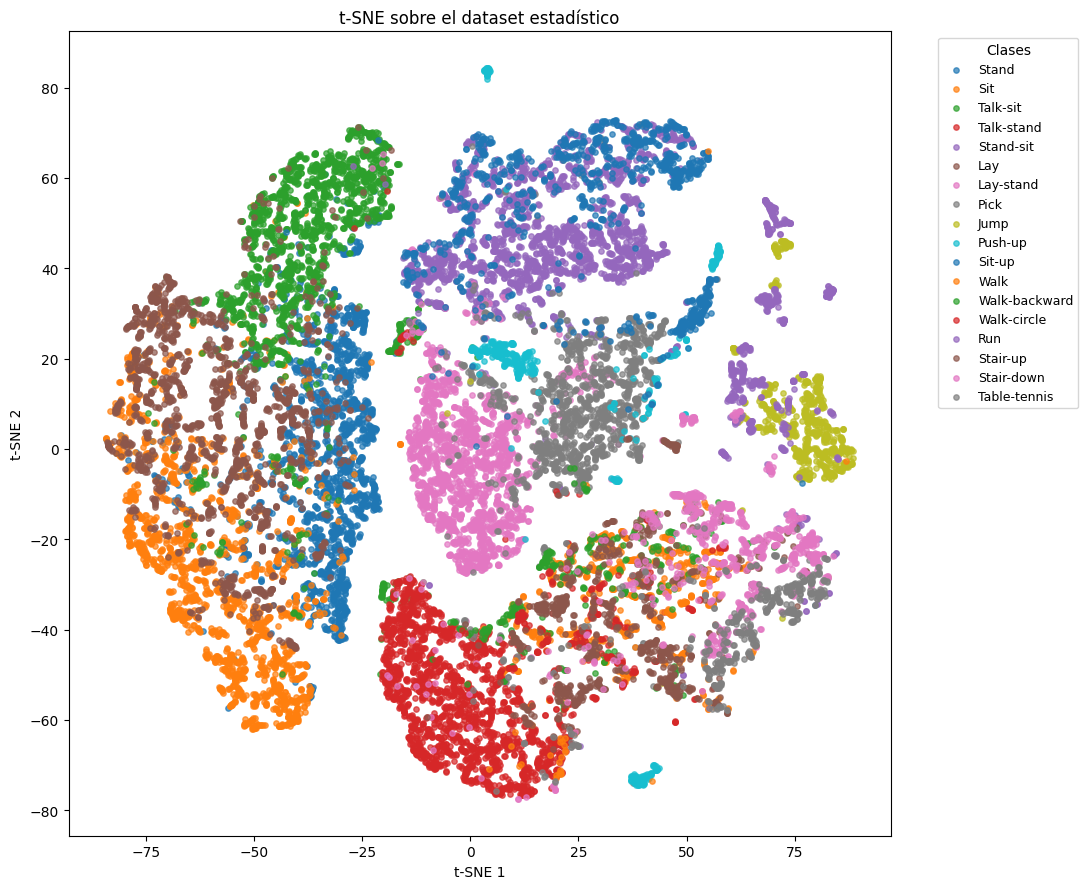

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(11, 9))

for label in sorted(df_tsne['label'].unique()):
    subset = df_tsne[df_tsne['label'] == label]
    plt.scatter(
        subset['TSNE1'],
        subset['TSNE2'],
        s=15,
        alpha=0.7,
        label=class_names[label]
    )

plt.legend(
    title='Clases',
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    fontsize=9
)

plt.title('t-SNE sobre el dataset estadístico')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.tight_layout()
plt.show()


En el gráfico generado poemos ver cómo las muestras de cada clase tienden a agruparse, auque no es fácil distinguir los distintos clusters en dos dimensiones (al igual que en el PCA).  

Vamos a probar a visualizarlo en 3D para ver si conseguimos distinguir mejor los clusters.

In [34]:
tsne3D= TSNE(
    n_components=3,
    perplexity=30,
    learning_rate=200,
    random_state=42
)

X_tsne_3d = tsne3D.fit_transform(X_tsne) 

df_tsne_3d = pd.DataFrame(
    X_tsne_3d,
    columns=['TSNE1', 'TSNE2', 'TSNE3']
)
df_tsne_3d['label'] = y

class_dict = dict(enumerate(class_names))

df_tsne_3d['class_name'] = df_tsne_3d['label'].map(class_dict)


# Plot 3D
fig = px.scatter_3d(
    df_tsne_3d,
    x='TSNE1',
    y='TSNE2',
    z='TSNE3',
    color='class_name',
    opacity=0.7,
    title='t-SNE 3D del dataset estadístico'
)

fig.show()

En la gráfica 3D results incluso más dificil distinguir los distintos clusters. Al igual que en la representación 2D se ve como las muestras de cada clase se agrupan entre ellas, aunque no se distingan de forma clara.

## Comparativa estadística  

Para hacer la comparación estadística del modelo lineal, Random Forest y XGBoost utilizaremos el test de Friedman, útil para escenarios con un mísmo dataset y más de dos algoritmos a comparar.  

Compararemos los resultados de F1-score obtenidos por los tres modelos al entrenarlos con clasificación cruzada de 3 capas.

In [19]:
from sklearn.model_selection import cross_val_score

cv = 3
scores_log = cross_val_score(best_log, X_stats, y, cv=cv, scoring="f1_weighted")
scores_rf = cross_val_score(best_rf, X_stats, y, cv=cv, scoring="f1_weighted")
scores_xgb = cross_val_score(best_xgb, X_stats, y, cv=cv, scoring="f1_weighted")

# imprimimos la media de los f1-score
print("Regresión logística:", scores_log.mean())
print("Random Forest:", scores_rf.mean())
print("XGboost:", scores_xgb.mean())

C:\Users\iraid\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\iraid\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase t

Regresión logística: 0.6548517998418321
Random Forest: 0.7977749171496238
XGboost: 0.8458560373182896


In [22]:
from scipy.stats import friedmanchisquare

stat, p = friedmanchisquare(
    scores_log,
    scores_rf,
    scores_xgb
)

print(f"Estadístico de Friedman: {stat:.4f}")
print(f"p-value: {p:.4f}")

Estadístico de Friedman: 6.0000
p-value: 0.0498


## Clasificación semisupervisada  

En este apartado exploraremos la siguientes técnicas de clasificación semisupervisada:  
- Self-training
- Co-trainig  
- Expectation-maximitation

En este contexto el algorítmo XGBoost resulta demasiado complejo, y random forest solamente es compatible con una técnica de clasificación semisupervisada, utilizaremos el clasificor de regresión logística.
  

Primero, probaremos con el 5% de los datos sin clasificar. Posteriormente aumentaremos el porcentaje a 10% y finalmente a 15%.  


In [60]:
import numpy as np
import pandas as pd
from sklearn.utils import shuffle
from sklearn.linear_model import LogisticRegression
from sklearn.semi_supervised import SelfTrainingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

### Self-trainig

In [61]:
def self_training_semi(X_labeled, y_labeled, X_unlabeled, y_unlabeled_real):
    model = LogisticRegression(penalty='l2', C=1.0, solver='lbfgs',
                               class_weight='balanced', max_iter=1000, random_state=42)
    
    self_train = SelfTrainingClassifier(model, threshold=0.8)
    
    y_unlabeled = np.array([-1]*len(X_unlabeled))
    X_train = pd.concat([X_labeled, X_unlabeled], axis=0)
    y_train = np.concatenate([y_labeled, y_unlabeled])
    
    self_train.fit(X_train, y_train)
    
    y_pred = self_train.predict(X_unlabeled)
    acc = accuracy_score(y_unlabeled_real, y_pred)
    
    return acc, y_pred

### Co-trainig

In [62]:
def co_training(X_labeled, y_labeled, X_unlabeled, y_unlabeled_real, n_iter=10, top_k=5):
    n_features = X_labeled.shape[1]
    
    view1 = X_labeled.iloc[:, :n_features//2].copy()
    view2 = X_labeled.iloc[:, n_features//2:].copy()
    
    X_unlabeled_view1 = X_unlabeled.iloc[:, :n_features//2].copy().reset_index(drop=True)
    X_unlabeled_view2 = X_unlabeled.iloc[:, n_features//2:].copy().reset_index(drop=True)
    
    clf1 = LogisticRegression(max_iter=1000, random_state=42)
    clf2 = LogisticRegression(max_iter=1000, random_state=42)
    
    y_unlabeled_pred = np.array([-1]*len(X_unlabeled))
    
    for _ in range(n_iter):
        clf1.fit(view1, y_labeled)
        clf2.fit(view2, y_labeled)
        
        probs1 = clf1.predict_proba(X_unlabeled_view1)
        probs2 = clf2.predict_proba(X_unlabeled_view2)
        
        top1 = np.argsort(np.max(probs1, axis=1))[-top_k:]
        top2 = np.argsort(np.max(probs2, axis=1))[-top_k:]
        
        y_unlabeled_pred[top1] = clf1.predict(X_unlabeled_view1.iloc[top1].to_numpy())
        y_unlabeled_pred[top2] = clf2.predict(X_unlabeled_view2.iloc[top2].to_numpy())
        
        view1 = pd.concat([view1, X_unlabeled_view1.iloc[top1]], axis=0)
        view2 = pd.concat([view2, X_unlabeled_view2.iloc[top2]], axis=0)
        y_labeled = np.concatenate([y_labeled, y_unlabeled_pred[top1]])
        
    acc = accuracy_score(y_unlabeled_real, y_unlabeled_pred)
    return acc, y_unlabeled_pred

### Expectation-maximization

In [63]:
def EM_semi(X_labeled, y_labeled, X_unlabeled, y_unlabeled_real, n_iter=10):
    clf = GaussianNB()
    X_l = X_labeled.copy()
    y_l = y_labeled.copy()
    X_u = X_unlabeled.copy()
    
    y_unlabeled_pred = np.zeros(len(X_u), dtype=int)
    
    for _ in range(n_iter):
        clf.fit(X_l, y_l)
        probs = clf.predict_proba(X_u)
        y_unlabeled_pred = np.argmax(probs, axis=1)
        X_l = pd.concat([X_l, X_u], axis=0)
        y_l = np.concatenate([y_l, y_unlabeled_pred])
        
    acc = accuracy_score(y_unlabeled_real, y_unlabeled_pred)
    return acc, y_unlabeled_pred

### Ejecución

In [64]:
X_shuffled, y_shuffled = shuffle(X_stats, y, random_state=42)
n_total = len(X_shuffled)

# Porcentajes de no etiquetados
percentages = [0.05, 0.10, 0.15]

for pct in percentages:
    n_unlabeled = int(pct * n_total)
    X_unlabeled = X_shuffled.iloc[:n_unlabeled].reset_index(drop=True)
    y_unlabeled_real = y_shuffled.iloc[:n_unlabeled]
    y_unlabeled = np.array([-1]*n_unlabeled)
    
    X_labeled = X_shuffled.iloc[n_unlabeled:].reset_index(drop=True)
    y_labeled = y_shuffled.iloc[n_unlabeled:]
    
    # Self-Training
    acc_self, _ = self_training_semi(X_labeled, y_labeled, X_unlabeled, y_unlabeled_real)
    
    # Co-Training
    acc_co, _ = co_training(X_labeled, y_labeled, X_unlabeled, y_unlabeled_real)
    
    # EM
    acc_em, _ = EM_semi(X_labeled, y_labeled, X_unlabeled, y_unlabeled_real)
    
    print(f"\n{int(pct*100)}% de muestras sin etiqueta:")
    print("Self-Training Accuracy:", round(acc_self, 4))
    print("Co-Training Accuracy:", round(acc_co, 4))
    print("EM Accuracy:", round(acc_em, 4))

C:\Users\iraid\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\iraid\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase t


5% de muestras sin etiqueta:
Self-Training Accuracy: 0.7165
Co-Training Accuracy: 0.0048
EM Accuracy: 0.4706


C:\Users\iraid\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\iraid\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase t


10% de muestras sin etiqueta:
Self-Training Accuracy: 0.7084
Co-Training Accuracy: 0.0034
EM Accuracy: 0.4766


C:\Users\iraid\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\iraid\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase t


15% de muestras sin etiqueta:
Self-Training Accuracy: 0.7147
Co-Training Accuracy: 0.0035
EM Accuracy: 0.4724


**5% de muestras sin etiqueta:**
Self-Training Accuracy: 0.7165  
Co-Training Accuracy: 0.0048  
EM Accuracy: 0.4706  


**10% de muestras sin etiqueta:**  
Self-Training Accuracy: 0.7084  
Co-Training Accuracy: 0.0034  
EM Accuracy: 0.4766  


**15% de muestras sin etiqueta:**  
Self-Training Accuracy: 0.7147  
Co-Training Accuracy: 0.0035  
EM Accuracy: 0.4724  


Como podemos observar en los resultados, self-training ha sido el método más efectivo en los tres escenarios, alcanzando al rededor del 70% de accuracy. Esto indica que el clasigicador base es capaz de aprender en escenarios de clasificación semi-supervisada y de clasificar muestras sin etiquetar de manera fiable.  
Mientras tanto, co-training ha mostrado un rendimiento prácticamente nulo en todos los casos. Esto se debe a que la técnica requiere vistas independientes y complementarias, pero en este dataset las dos mitades de las variables predictoras no aportan información suficientemente distinta. Además, un problema con 18 clases dificulta la elección de pseudoetiquetas confiables.  
Por último, EM se ha mantenido un rendimiento intermedio en los tres casos.Aunque mejora respecto al modelo anterior, su desempeño está limitado por las suposiciones de independencia condicional y distribución gaussiana de las features, que no se cumplen completamente en este dataset.  

Como conclusión final, podemos ver que aumentar la proporción de datos no etiquetados del 5% al 15% no produce cambios significativos en ninguno de los modelos.